# Statistical Analysis of Turkish Makam Music SymbTr v3.0 Dataset

The SymbTr v3.0 dataset provides a numerical representation of Turkish makam music by encoding complete musical scores as fixed-length feature vectors. Unlike the annotation-based phrase datasets presented later in this notebook, SymbTr is designed for statistical learning and machine learning applications, where each musical piece is represented by a set of numerical attributes.

The dataset supports exploratory data analysis, statistical modeling, dimensionality reduction, clustering, similarity analysis, and machine learning. The following statistical analyses examine the numerical characteristics of the dataset and establish a reproducible foundation for subsequent computational analyses.

## Why Perform Statistical Analysis on the SymbTr v3.0 Dataset?

Statistical analysis is a fundamental step in understanding the structure and numerical characteristics of the SymbTr v3.0 dataset before applying advanced computational methods. By examining descriptive statistics, missing-value patterns, feature variability, and relationships among numerical features, researchers can gain valuable insights into the quality, complexity, and representativeness of the dataset.

These analyses help identify potential data characteristics that may influence subsequent machine learning and music information retrieval (MIR) tasks, such as dimensionality reduction, clustering, similarity analysis, and classification. Furthermore, statistical exploration provides an evidence-based foundation for selecting appropriate preprocessing techniques and interpreting the results of later computational analyses.

Within this tutorial, the statistical analyses presented in this section are intended not only to describe the dataset but also to guide readers through a reproducible exploratory workflow that supports a deeper understanding of symbolic Turkish makam music data. The findings obtained here serve as the basis for the visualization, Principal Component Analysis (PCA), clustering, and similarity analyses presented in the following chapters.

## Dataset Overview

The SymbTr V3.0 dataset contains symbolic representations of Turkish makam music encoded as numerical time-series features. The following table summarizes the overall numerical characteristics of the dataset, including the number of observations, numerical features, missing values, and global descriptive statistics. This overview provides an initial understanding of the dataset before more detailed statistical analyses are performed.

In [146]:
overview_rows = []

values = datasets["SymbTr"].stack()

overview_rows.append({
    "Dataset":"SymbTr",
    "Observations":datasets["SymbTr"].shape[0],
    "Numeric Features":datasets["SymbTr"].shape[1],
    "Missing Values":datasets["SymbTr"].isnull().sum().sum(),
    "Mean":values.mean(),
    "Median":values.median(),
    "Standard Deviation":values.std(),
    "Minimum":values.min(),
    "Maximum":values.max()
})

pd.DataFrame(overview_rows).round(2)

,Dataset,Observations,Numeric Features,Missing Values,Mean,Median,Standard Deviation,Minimum,Maximum
0,SymbTr,3000,365,20293,325.29,327.0,22.45,0.0,402.0


## Missing Value Analysis

This section examines the occurrence of missing values in the dataset. Identifying incomplete observations is an important preprocessing step before performing statistical analyses and machine learning.

In [147]:
# =============================================================================
# Missing value analysis
# =============================================================================

for name, data in datasets.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    missing = data.isnull().sum()

    print(f"Total missing values        : {missing.sum()}")
    print(f"Columns with missing values : {(missing > 0).sum()}")

    missing_df = (
        missing[missing > 0]
        .sort_values(ascending=False)
        .to_frame("Missing Values")
    )

    display(missing_df)

SymbTr
Total missing values        : 20293
Columns with missing values : 363


,Missing Values
p183,351
p184,195
p92,179
p182,174
p91,166
...,...
p2,10
p360,10
p361,10
p363,5


## Interpretation of the Missing Values in the SymbTr V3.0 Dataset

The missing values observed in the SymbTr V3.0 dataset originate from the variable temporal lengths of symbolic music pieces rather than from incomplete or erroneous measurements. Since all pieces are represented within a fixed-length time-series matrix, shorter pieces are naturally padded with missing values (NaN). Consequently, these missing values reflect structural characteristics of the dataset rather than data quality issues.

## Global Descriptive Statistics
 Global Descriptive Statistics

This section summarizes the overall numerical characteristics of each dataset. The reported statistics provide a general overview of the distribution of numerical values before feature-level analyses are performed.

In [153]:
# =============================================================================
# Global descriptive statistics
# =============================================================================

for name, data in datasets.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    values = data.stack()

    global_stats = pd.DataFrame({
        "Statistic": [
            "Observations",
            "Numeric Features",
            "Mean",
            "Median",
            "Standard Deviation",
            "Minimum",
            "Maximum"
        ],
        "Value": [
            data.shape[0],
            data.shape[1],
            values.mean(),
            values.median(),
            values.std(),
            values.min(),
            values.max()
        ]
    })

    display(global_stats.round(2))

SymbTr


,Statistic,Value
0,Observations,3000.00
1,Numeric Features,365.00
2,Mean,325.29
3,Median,327.00
4,Standard Deviation,22.45
5,Minimum,0.00
6,Maximum,402.00


In [144]:
# =============================================================================
# Feature-wise descriptive statistics
# =============================================================================

for name, data in datasets.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    feature_stats = data.describe().T.round(2)

    display(feature_stats)

SymbTr


,count,mean,std,min,25%,50%,75%,max
p1,2999.0,324.26,20.55,230.0,305.0,327.0,340.0,380.0
p2,2990.0,326.95,19.82,230.0,313.0,327.0,344.0,380.0
p3,2988.0,328.30,19.91,230.0,314.0,327.0,344.0,380.0
p4,2976.0,328.46,19.54,221.0,318.0,327.0,344.0,380.0
p5,2967.0,328.05,19.86,221.0,318.0,327.0,340.0,380.0
...,...,...,...,...,...,...,...,...
p361,2990.0,306.78,14.67,230.0,296.0,305.0,313.0,380.0
p362,2989.0,305.17,13.75,243.0,296.0,305.0,313.0,384.0
p363,2995.0,303.36,12.86,243.0,296.0,305.0,305.0,402.0
p364,3000.0,301.80,11.70,230.0,296.0,305.0,305.0,402.0


## Piece-wise Descriptive Statistics

This section computes the average numerical feature value for each musical piece and summarizes the distribution of these averages across each dataset.

In [143]:
# =============================================================================
# Piece-wise descriptive statistics
# =============================================================================

for name, data in datasets.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    piece_means = data.mean(axis=1)

    piece_summary = piece_means.describe().to_frame("Value").round(2)

    display(piece_summary)

SymbTr


,Value
count,3000.00
mean,325.33
std,8.18
min,289.49
25%,320.02
50%,325.54
75%,331.14
max,354.92


In [142]:
piece_variances = X.var(axis=1)

piece_variances.describe()

count    3000.000000
mean      435.237686
std       259.467586
min        34.616901
25%       248.752011
50%       360.911748
75%       559.372829
max      2110.490095
dtype: float64

## Distribution of Mean Feature Values

The following histograms illustrate the distribution of the average numerical feature values for each musical piece. The mean and median are highlighted to facilitate comparison of the central tendency and overall distribution across datasets.

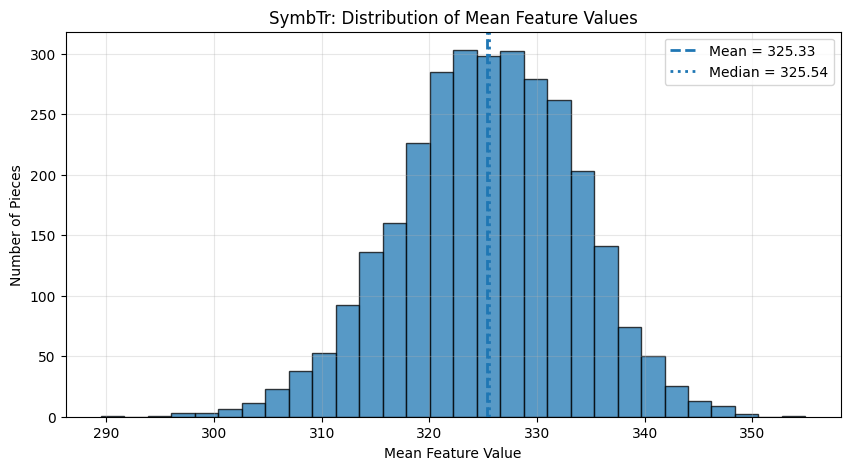

In [106]:
# =============================================================================
# Distribution of mean feature values
# =============================================================================

for name, data in datasets.items():

    piece_means = data.mean(axis=1)

    plt.figure(figsize=(10, 5))

    plt.hist(
        piece_means,
        bins=30,
        edgecolor="black",
        alpha=0.75
    )

    plt.axvline(
        piece_means.mean(),
        linestyle="--",
        linewidth=2,
        label=f"Mean = {piece_means.mean():.2f}"
    )

    plt.axvline(
        piece_means.median(),
        linestyle=":",
        linewidth=2,
        label=f"Median = {piece_means.median():.2f}"
    )

    plt.title(f"{name}: Distribution of Mean Feature Values")
    plt.xlabel("Mean Feature Value")
    plt.ylabel("Number of Pieces")

    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

## Feature Variability Analysis

Feature variability provides important information about the distribution of numerical characteristics within the dataset. Features with very low variance often contribute little discriminatory information, whereas highly variable features are more likely to capture meaningful differences among musical pieces.

Examining feature variance therefore serves two purposes. First, it offers a better understanding of the statistical properties of the SymbTr dataset. Second, it provides an intuitive motivation for subsequent dimensionality reduction techniques, such as Principal Component Analysis (PCA), where highly informative features contribute more effectively to the extracted principal components.

In [105]:
# =============================================================================
# Feature variability analysis
# =============================================================================

for name, data in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    feature_variance = (
        data.var()
        .sort_values(ascending=False)
        .to_frame(name="Variance")
    )

    display(feature_variance.round(2))

SymbTr


,Variance
p183,1222.69
p184,922.34
p92,875.66
p274,807.45
p275,805.85
...,...
p361,215.18
p362,189.18
p363,165.25
p364,136.81


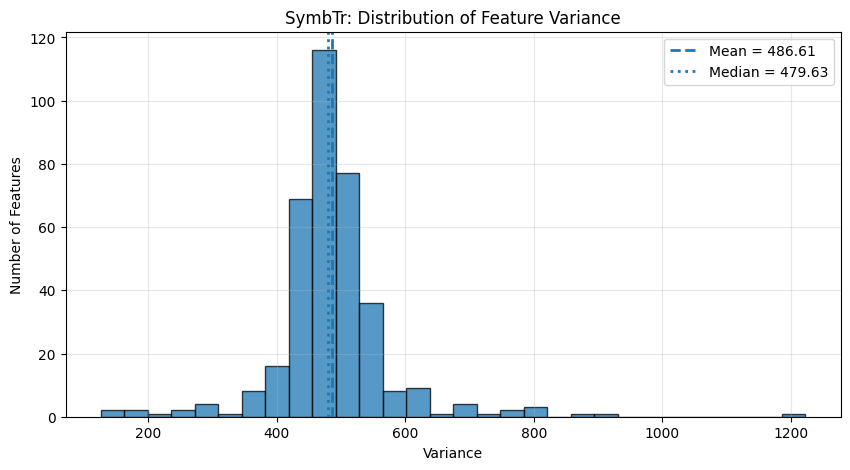

In [104]:
# =============================================================================
# Distribution of feature variance
# =============================================================================

for name, data in datasets.items():

    feature_variance = data.var()

    plt.figure(figsize=(10,5))

    plt.hist(
        feature_variance,
        bins=30,
        edgecolor="black",
        alpha=0.75
    )

    plt.axvline(
        feature_variance.mean(),
        linestyle="--",
        linewidth=2,
        label=f"Mean = {feature_variance.mean():.2f}"
    )

    plt.axvline(
        feature_variance.median(),
        linestyle=":",
        linewidth=2,
        label=f"Median = {feature_variance.median():.2f}"
    )

    plt.title(f"{name}: Distribution of Feature Variance")
    plt.xlabel("Variance")
    plt.ylabel("Number of Features")

    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

In [103]:
# =============================================================================
# Comparative summary
# =============================================================================

comparison = []

for name, data in datasets.items():

    values = data.stack()

    comparison.append({
        "Dataset": name,
        "Pieces": data.shape[0],
        "Features": data.shape[1],
        "Missing Values": int(data.isnull().sum().sum()),
        "Mean": values.mean(),
        "Median": values.median(),
        "Std": values.std(),
        "Minimum": values.min(),
        "Maximum": values.max()
    })

comparison_df = pd.DataFrame(comparison)

comparison_df.round(2)

,Dataset,Pieces,Features,Missing Values,Mean,Median,Std,Minimum,Maximum
0,SymbTr,3000,365,20293,325.29,327.0,22.45,0.0,402.0


## Correlation Analysis

This section examines pairwise correlations among numerical features in the SymbTr dataset. Correlation analysis helps identify relationships and possible redundancy among features before applying dimensionality reduction methods such as PCA.

In [154]:
# =============================================================================
# Correlation analysis
# =============================================================================

symbtr_data = datasets["SymbTr"]

correlation_matrix = symbtr_data.corr()

correlation_matrix.round(2)

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p356,p357,p358,p359,p360,p361,p362,p363,p364,p365
p1,1.00,0.85,0.73,0.62,0.56,0.51,0.48,0.48,0.41,0.41,...,0.05,0.05,0.04,0.06,0.06,0.03,0.02,0.02,0.02,0.02
p2,0.85,1.00,0.83,0.69,0.63,0.57,0.49,0.51,0.45,0.43,...,0.06,0.08,0.05,0.05,0.05,0.03,0.02,0.02,0.01,0.01
p3,0.73,0.83,1.00,0.76,0.68,0.61,0.52,0.51,0.46,0.46,...,0.08,0.08,0.07,0.06,0.06,0.05,0.03,0.03,0.02,0.01
p4,0.62,0.69,0.76,1.00,0.74,0.62,0.53,0.54,0.48,0.46,...,0.07,0.05,0.07,0.04,0.05,0.05,0.02,0.03,0.02,0.01
p5,0.56,0.63,0.68,0.74,1.00,0.71,0.56,0.53,0.48,0.48,...,0.07,0.07,0.04,0.03,0.06,0.05,0.02,0.04,0.02,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
p361,0.03,0.03,0.05,0.05,0.05,0.03,0.02,-0.00,0.04,0.04,...,0.46,0.48,0.51,0.58,0.70,1.00,0.70,0.61,0.62,0.61
p362,0.02,0.02,0.03,0.02,0.02,0.01,0.01,0.00,0.02,-0.00,...,0.47,0.47,0.50,0.55,0.59,0.70,1.00,0.75,0.69,0.68
p363,0.02,0.02,0.03,0.03,0.04,0.01,0.02,0.05,0.03,0.02,...,0.41,0.44,0.46,0.52,0.55,0.61,0.75,1.00,0.82,0.79
p364,0.02,0.01,0.02,0.02,0.02,0.01,0.01,0.02,0.04,0.02,...,0.43,0.45,0.47,0.53,0.57,0.62,0.69,0.82,1.00,0.91


## Correlation Heatmap

The following heatmap visualizes the pairwise correlations among numerical features. The graphical representation makes it easier to identify groups of highly correlated variables and overall dependency patterns within the dataset.

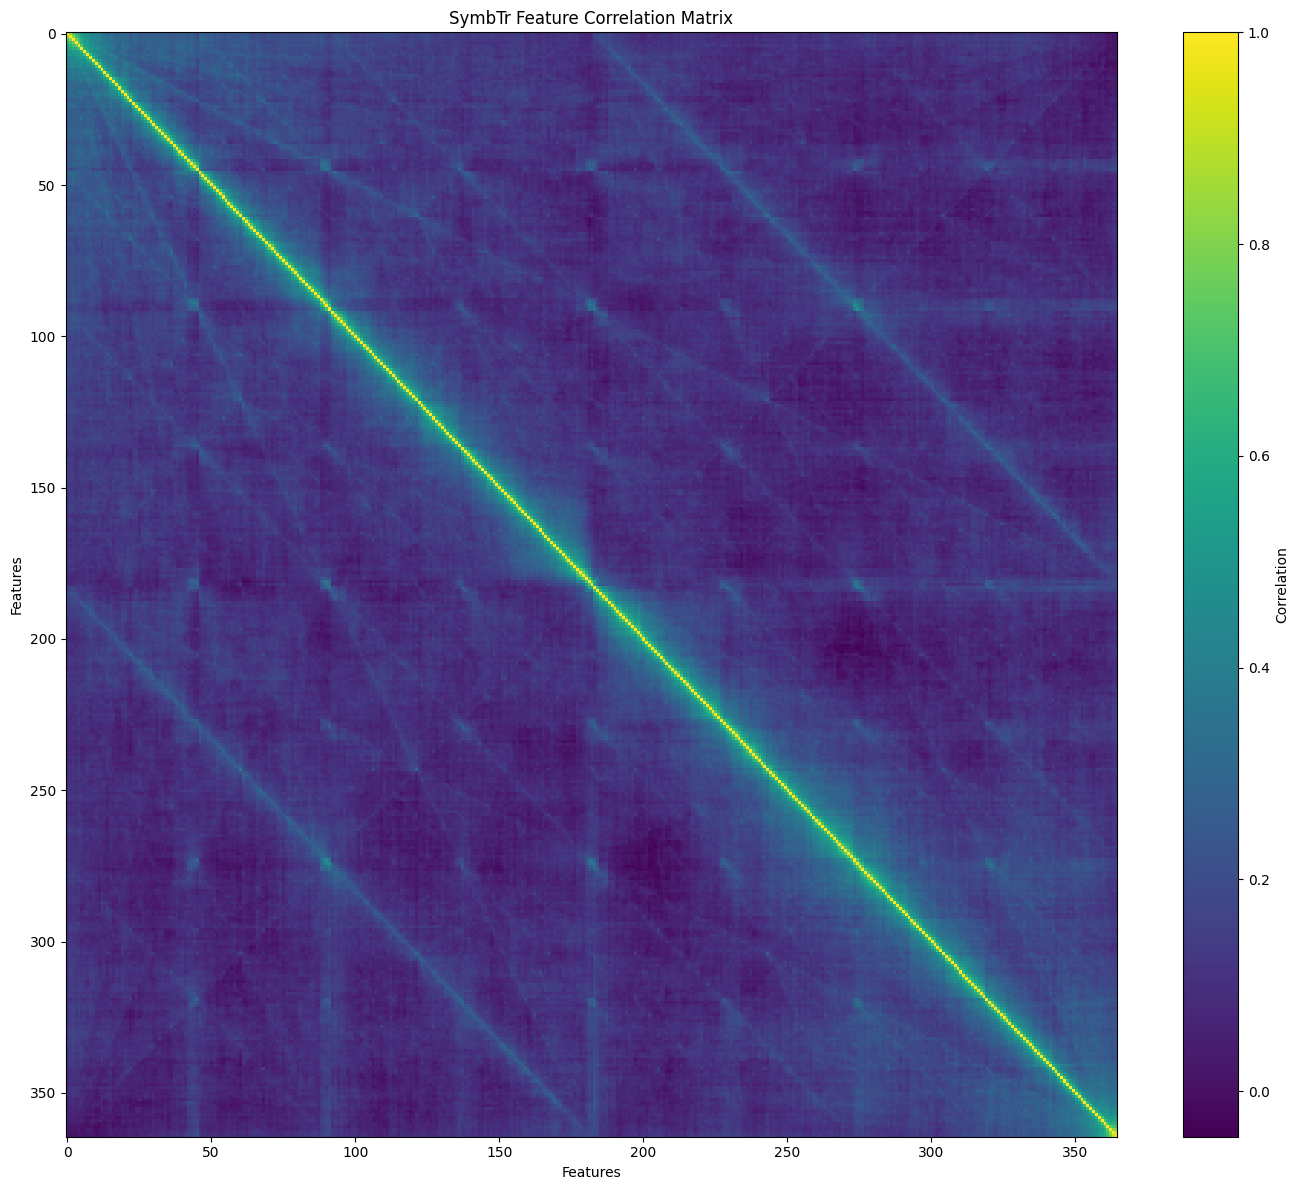

In [101]:
# =============================================================================
# Correlation heatmap
# =============================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    interpolation="nearest"
)

plt.title("SymbTr Feature Correlation Matrix")

plt.xlabel("Features")
plt.ylabel("Features")

plt.colorbar(label="Correlation")

plt.tight_layout()

plt.show()

## Interpretation of the Correlation Structure

The correlation matrix provides an overview of the dependency structure among the numerical features extracted from the SymbTr dataset. Highly correlated features may contain redundant information, whereas weakly correlated features often capture complementary musical characteristics.

Such redundancy is common in high-dimensional music representations, where multiple descriptors characterize similar acoustic or symbolic properties. Consequently, reducing the dimensionality of the feature space becomes beneficial for both visualization and machine learning.

The next notebook introduces Principal Component Analysis (PCA), which transforms the original correlated feature space into a smaller set of orthogonal components while preserving most of the variance contained in the data.

## Next Step

The next notebook focuses on **Visualization**, where the statistical findings presented in this chapter are explored through graphical representations of Turkish Makam Music SymbTr v3.0 Dataset. These visual analyses complement the statistical summaries by revealing structural patterns, feature distributions, melodic characteristics, and annotation properties that are more easily interpreted through visual exploration.

Together, the statistical and visual analyses establish a comprehensive exploratory data analysis (EDA) workflow that prepares the datasets for subsequent computational methods, including principal component analysis (PCA), clustering, similarity analysis, and machine learning.